In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('/app')
from database.db_connection import get_connection

conn = get_connection()

# Đọc thẳng từ VIEW ml_features đã thiết kế sẵn
df = pd.read_sql("SELECT * FROM ml_features", conn)
conn.close()

print(f"Shape: {df.shape}")
print(f"\nCác cột: {df.columns.tolist()}")
df.head()

Shape: (992, 15)

Các cột: ['listing_id', 'price_vnd', 'area_m2', 'district_id', 'district_name', 'price_per_m2', 'has_wc', 'has_ac', 'has_balcony', 'has_kitchen', 'has_parking', 'has_security', 'share_ownership', 'floor_number', 'scraped_at']


/tmp/ipykernel_18/2373473735.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM ml_features", conn)


,listing_id,price_vnd,area_m2,district_id,district_name,price_per_m2,has_wc,has_ac,has_balcony,has_kitchen,has_parking,has_security,share_ownership,floor_number,scraped_at
0,1,4800000,35.0,18,T??n Ph??,137142.857143,False,False,False,False,False,True,False,None,2026-04-05 14:00:34.477
1,2,6000000,25.0,3,Qu???n 3,240000.000000,False,False,True,False,False,False,False,None,2026-04-05 14:00:34.517
2,3,3500000,25.0,17,T??n B??nh,140000.000000,True,False,False,True,True,False,False,None,2026-04-05 14:00:34.523
3,4,3500000,25.0,18,T??n Ph??,140000.000000,False,False,False,False,False,False,False,None,2026-04-05 14:00:34.530
4,5,3300000,35.0,12,Qu???n 12,94285.714286,False,False,True,False,False,False,False,None,2026-04-05 14:00:34.537


In [3]:
print("=== THÔNG TIN TỔNG QUAN ===")
print(df.info())

print("\n=== GIÁ TRỊ NULL ===")
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(null_pct[null_pct > 0])

print("\n=== THỐNG KÊ MÔ TẢ ===")
df[["price_vnd", "area_m2", "price_per_m2"]].describe()


=== THÔNG TIN TỔNG QUAN ===
<class 'pandas.DataFrame'>
RangeIndex: 992 entries, 0 to 991
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   listing_id       992 non-null    int64         
 1   price_vnd        992 non-null    int64         
 2   area_m2          992 non-null    float64       
 3   district_id      992 non-null    int64         
 4   district_name    992 non-null    str           
 5   price_per_m2     992 non-null    float64       
 6   has_wc           992 non-null    bool          
 7   has_ac           992 non-null    bool          
 8   has_balcony      992 non-null    bool          
 9   has_kitchen      992 non-null    bool          
 10  has_parking      992 non-null    bool          
 11  has_security     992 non-null    bool          
 12  share_ownership  992 non-null    bool          
 13  floor_number     0 non-null      object        
 14  scraped_at       992 non-

,price_vnd,area_m2,price_per_m2
count,9.920000e+02,992.000000,992.000000
mean,3.646429e+06,28.239315,143728.629670
std,2.711777e+06,14.371713,67561.668688
min,3.300000e+01,8.000000,1.650000
25%,2.600000e+06,20.000000,113333.333333
50%,3.500000e+06,25.000000,145000.000000
75%,4.500000e+06,30.000000,177142.857143
max,7.000000e+07,100.000000,933333.333333


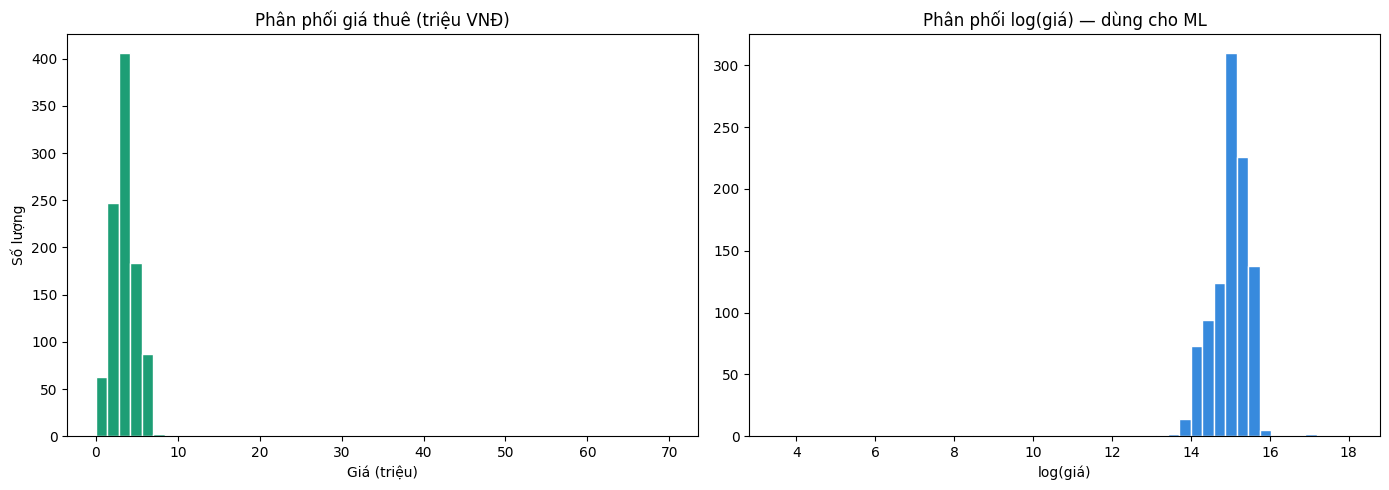

Giá trung bình : 3.6 triệu
Giá trung vị   : 3.5 triệu
Giá thấp nhất  : 0.0 triệu
Giá cao nhất   : 70.0 triệu


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Phân phối gốc — thường bị skew (lệch phải)
axes[0].hist(df["price_vnd"] / 1e6, bins=50, color="#1D9E75", edgecolor="white")
axes[0].set_title("Phân phối giá thuê (triệu VNĐ)")
axes[0].set_xlabel("Giá (triệu)")
axes[0].set_ylabel("Số lượng")

# Log transform — giúp model học tốt hơn
import numpy as np
axes[1].hist(np.log1p(df["price_vnd"]), bins=50, color="#378ADD", edgecolor="white")
axes[1].set_title("Phân phối log(giá) — dùng cho ML")
axes[1].set_xlabel("log(giá)")

plt.tight_layout()
plt.savefig("/app/data/dist_price.png", dpi=150)
plt.show()

print(f"Giá trung bình : {df['price_vnd'].mean()/1e6:.1f} triệu")
print(f"Giá trung vị   : {df['price_vnd'].median()/1e6:.1f} triệu")
print(f"Giá thấp nhất  : {df['price_vnd'].min()/1e6:.1f} triệu")
print(f"Giá cao nhất   : {df['price_vnd'].max()/1e6:.1f} triệu")

In [5]:
# Outlier = giá quá thấp hoặc quá cao bất thường
Q1 = df["price_vnd"].quantile(0.25)
Q3 = df["price_vnd"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["price_vnd"] < lower) | (df["price_vnd"] > upper)]
print(f"Số outlier: {len(outliers)} / {len(df)} ({len(outliers)/len(df)*100:.1f}%)")
print(f"Ngưỡng hợp lệ: {lower/1e6:.1f} → {upper/1e6:.1f} triệu")
print(f"\nCác outlier cao nhất:")
print(outliers.nlargest(5, "price_vnd")[["listing_id", "price_vnd", "area_m2", "district_name"]])

# Lọc outlier ra khỏi df cho ML
df_clean = df[(df["price_vnd"] >= lower) & (df["price_vnd"] <= upper)]
print(f"\nSau lọc outlier: {len(df_clean)} dòng còn lại")

Số outlier: 6 / 992 (0.6%)
Ngưỡng hợp lệ: -0.2 → 7.3 triệu

Các outlier cao nhất:
     listing_id  price_vnd  area_m2  district_name
11           12   70000000     75.0       Qu???n 2
501         507   26500000     35.0       C??? Chi
871         879   24000000     40.0       Qu???n 1
146         149    8600000     40.0  B??nh Th???nh
257         262    8000000     35.0       Qu???n 5

Sau lọc outlier: 986 dòng còn lại


In [6]:
print(df.columns)

Index(['listing_id', 'price_vnd', 'area_m2', 'district_id', 'district_name',
       'price_per_m2', 'has_wc', 'has_ac', 'has_balcony', 'has_kitchen',
       'has_parking', 'has_security', 'share_ownership', 'floor_number',
       'scraped_at'],
      dtype='str')
